In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("data.csv")
df.head()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


In [6]:
df.info

<bound method DataFrame.info of       Bankrupt?   ROA(C) before interest and depreciation before interest  \
0             1                                           0.370594          
1             1                                           0.464291          
2             1                                           0.426071          
3             1                                           0.399844          
4             1                                           0.465022          
...         ...                                                ...          
6814          0                                           0.493687          
6815          0                                           0.475162          
6816          0                                           0.472725          
6817          0                                           0.506264          
6818          0                                           0.493053          

       ROA(A) before interest and % after t

In [8]:
df.describe

<bound method NDFrame.describe of       Bankrupt?   ROA(C) before interest and depreciation before interest  \
0             1                                           0.370594          
1             1                                           0.464291          
2             1                                           0.426071          
3             1                                           0.399844          
4             1                                           0.465022          
...         ...                                                ...          
6814          0                                           0.493687          
6815          0                                           0.475162          
6816          0                                           0.472725          
6817          0                                           0.506264          
6818          0                                           0.493053          

       ROA(A) before interest and % after

In [10]:
df.shape

(6819, 96)

In [12]:
df.size

654624

In [14]:
df.isnull().sum()

Bankrupt?                                                   0
 ROA(C) before interest and depreciation before interest    0
 ROA(A) before interest and % after tax                     0
 ROA(B) before interest and depreciation after tax          0
 Operating Gross Margin                                     0
                                                           ..
 Liability to Equity                                        0
 Degree of Financial Leverage (DFL)                         0
 Interest Coverage Ratio (Interest expense to EBIT)         0
 Net Income Flag                                            0
 Equity to Liability                                        0
Length: 96, dtype: int64

In [16]:
df.dtypes

Bankrupt?                                                     int64
 ROA(C) before interest and depreciation before interest    float64
 ROA(A) before interest and % after tax                     float64
 ROA(B) before interest and depreciation after tax          float64
 Operating Gross Margin                                     float64
                                                             ...   
 Liability to Equity                                        float64
 Degree of Financial Leverage (DFL)                         float64
 Interest Coverage Ratio (Interest expense to EBIT)         float64
 Net Income Flag                                              int64
 Equity to Liability                                        float64
Length: 96, dtype: object

In [72]:
df.columns = df.columns.str.strip()

In [74]:
df.columns

Index(['Bankrupt?', 'ROA(C) before interest and depreciation before interest',
       'ROA(A) before interest and % after tax',
       'ROA(B) before interest and depreciation after tax',
       'Operating Gross Margin', 'Realized Sales Gross Margin',
       'Operating Profit Rate', 'Pre-tax net Interest Rate',
       'After-tax net Interest Rate',
       'Non-industry income and expenditure/revenue',
       'Continuous interest rate (after tax)', 'Operating Expense Rate',
       'Research and development expense rate', 'Cash flow rate',
       'Interest-bearing debt interest rate', 'Tax rate (A)',
       'Net Value Per Share (B)', 'Net Value Per Share (A)',
       'Net Value Per Share (C)', 'Persistent EPS in the Last Four Seasons',
       'Cash Flow Per Share', 'Revenue Per Share (Yuan ¥)',
       'Operating Profit Per Share (Yuan ¥)',
       'Per Share Net profit before tax (Yuan ¥)',
       'Realized Sales Gross Profit Growth Rate',
       'Operating Profit Growth Rate', 'After-tax

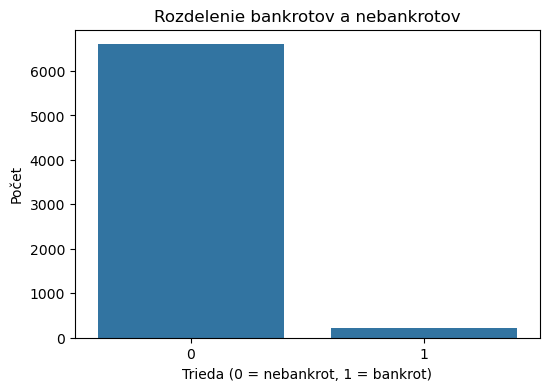

In [20]:
plt.figure(figsize=(6,4))
sns.countplot(x='Bankrupt?', data=df)
plt.title("Rozdelenie bankrotov a nebankrotov")
plt.xlabel("Trieda (0 = nebankrot, 1 = bankrot)")
plt.ylabel("Počet")
plt.show()


#Graf znázorňuje rozdelenie tried v datasete. 
#Je možné pozorovať, že dáta sú nevyvážené.

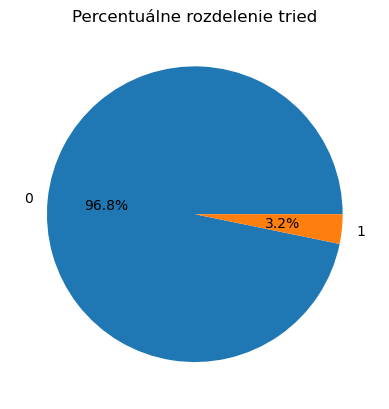

In [22]:
df['Bankrupt?'].value_counts(normalize=True).plot(
    kind='pie', autopct='%1.1f%%'
)

plt.title("Percentuálne rozdelenie tried")
plt.ylabel("")
plt.show()

#Miera nevyváženosti dát.
#Percentuálne zastúpenie tried potvrdzuje výraznú dominanciu nebankrotujúcich podnikov.
#Z grafu rozdelenia tried je zrejmé, že dataset obsahuje výrazne viac 
#nebankrotujúcich podnikov (trieda 0) ako bankrotujúcich (trieda 1).
#Tento jav poukazuje na nevyváženosť dát (class imbalance), 
#ktorá môže negatívne ovplyvniť presnosť klasifikačných modelov, najmä pri predikcii menšinovej triedy.
#Preto bude potrebné zvážiť použitie techník ako napríklad váhovanie tried.

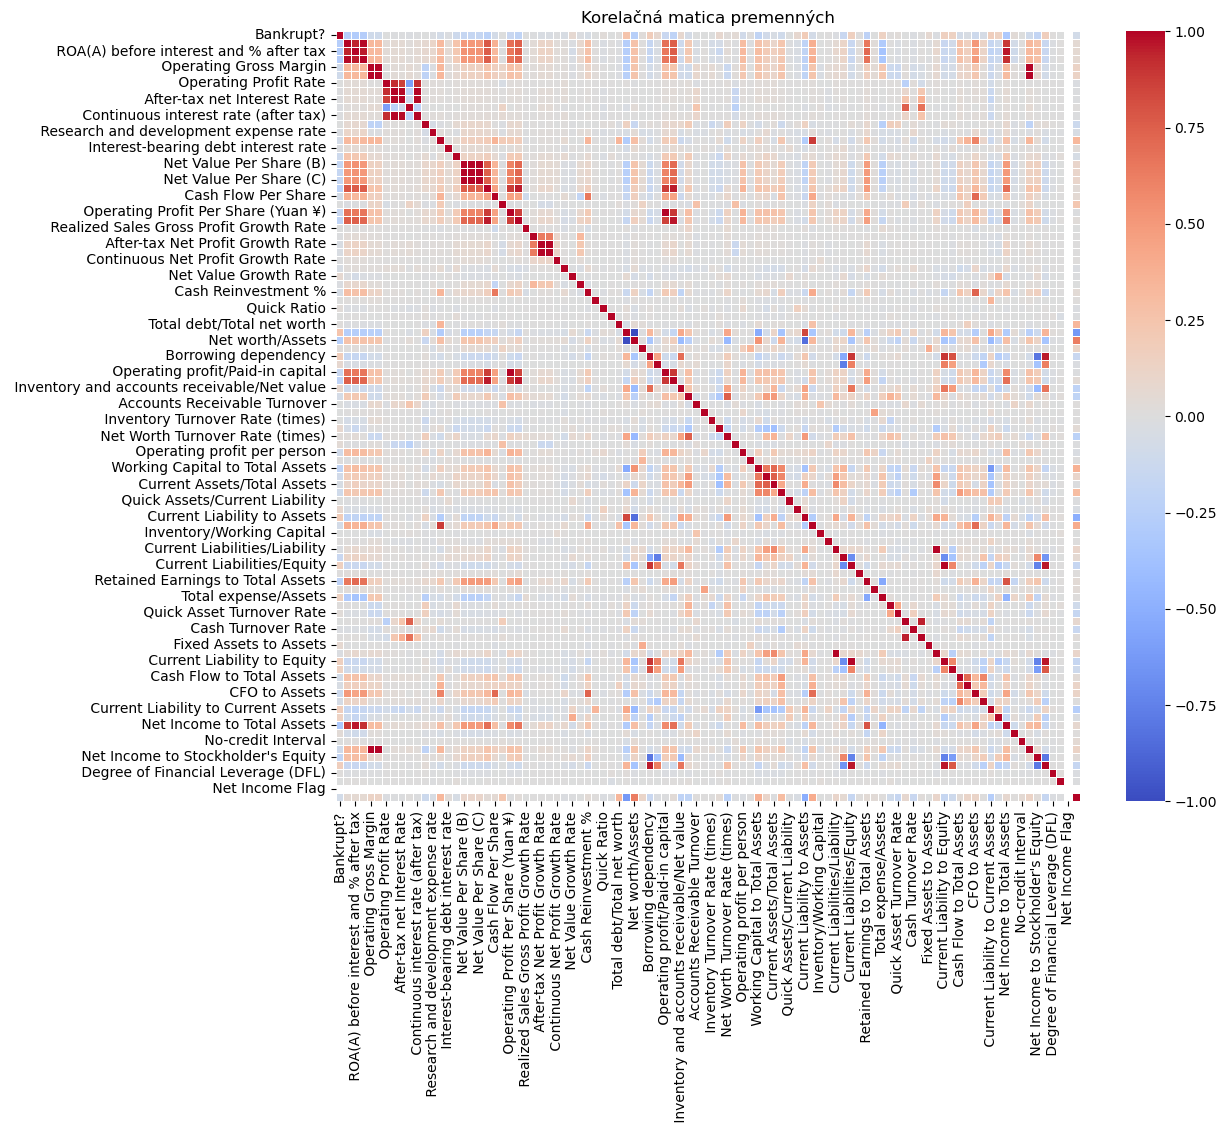

In [24]:
plt.figure(figsize=(12,10))
corr = df.corr()
sns.heatmap(corr, cmap="coolwarm", linewidths=0.5)
plt.title("Korelačná matica premenných")
plt.show()

#Identifikácia vzťahov medzi premennými
#Korelačná matica poskytuje prehľad o vzťahoch medzi jednotlivými premennými

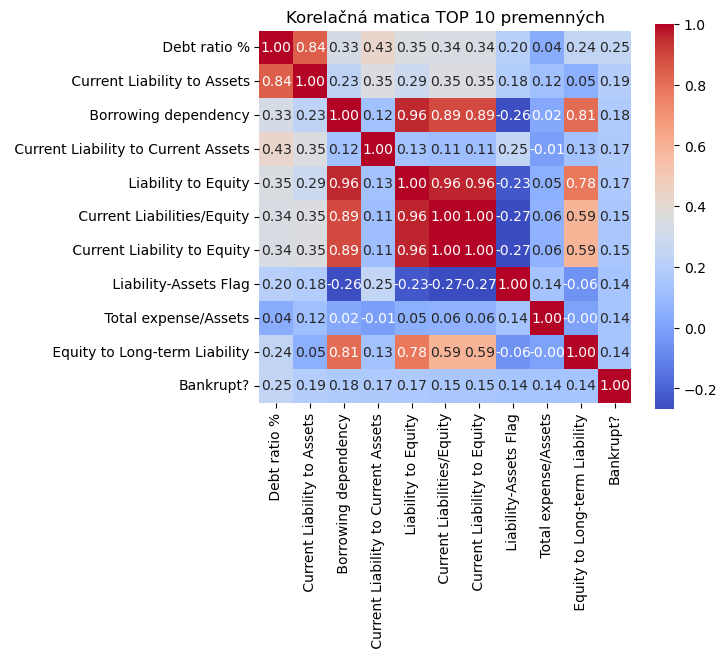

In [70]:
corr_target = df.corr()['Bankrupt?'].sort_values(ascending=False)
top_features = corr_target[1:11].index.tolist()
top_features.append('Bankrupt?')
df_top = df[top_features]

corr_matrix = df_top.corr()
plt.figure(figsize=(6,5))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True
)

plt.title("Korelačná matica TOP 10 premenných")
plt.show()

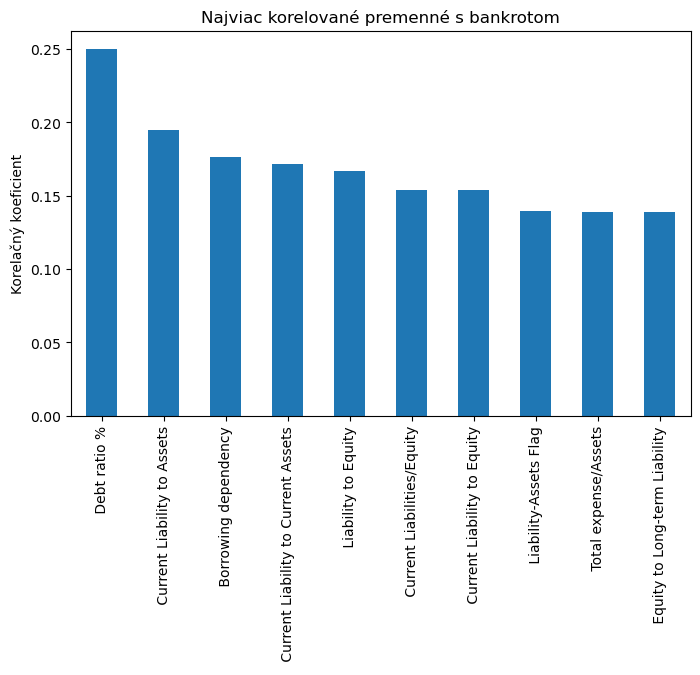

In [28]:
corr_target = df.corr()['Bankrupt?'].sort_values(ascending=False)
top_corr = corr_target[1:11]
plt.figure(figsize=(8,5))
top_corr.plot(kind='bar')
plt.title("Najviac korelované premenné s bankrotom")
plt.ylabel("Korelačný koeficient")
plt.show()


#Analýza korelácie s cieľovou premennou „Bankrupt?“ ukazuje, ktoré finančné 
#ukazovatele majú najväčší vplyv na pravdepodobnosť bankrotu.

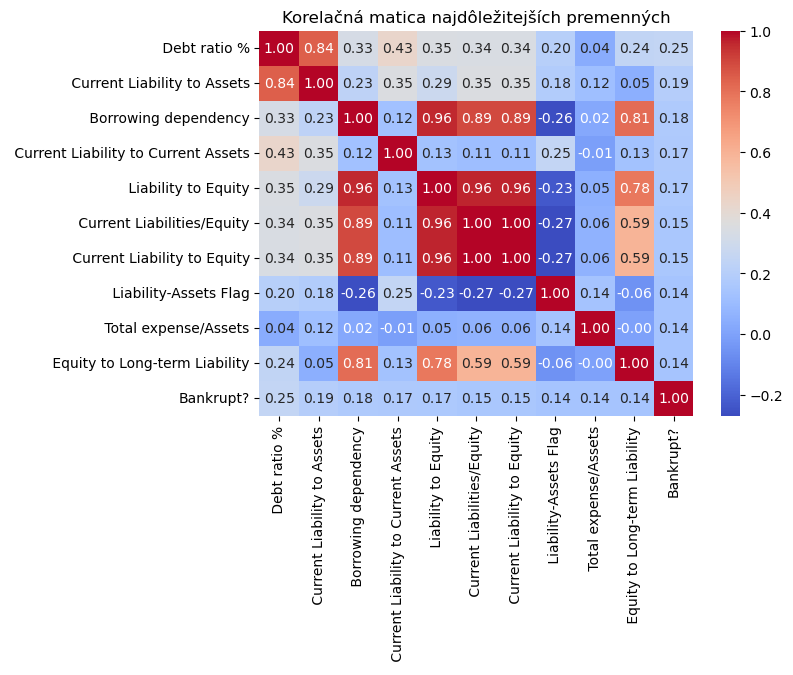

In [44]:
top_features = top_corr.index.tolist()
top_features.append('Bankrupt?')
df_top = df[top_features]

plt.figure(figsize=(7,5))
sns.heatmap(df_top.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Korelačná matica najdôležitejších premenných")
plt.show()


#Korelačná matica najvýznamnejších premenných poskytuje detailnejší pohľad na vzťahy 
#medzi faktormi ovplyvňujúcimi bankrot podniku.

#Korelačná matica ukazuje, že pomer zadlženosti (Debt ratio %) má najvyššiu, 
#ale stále len miernu pozitívnu koreláciu s bankrotom (Bankrupt?). 
#Podobne aj podiel krátkodobých záväzkov na aktívach (Current Liability to Assets)
#a závislosť od úverov (Borrowing dependency) súvisia s vyšším rizikom bankrotu. 
#Celkovo graf potvrdzuje, že riziko bankrotu najviac súvisí najmä s 
#mierou zadlženosti a kapitálovou štruktúrou podniku.

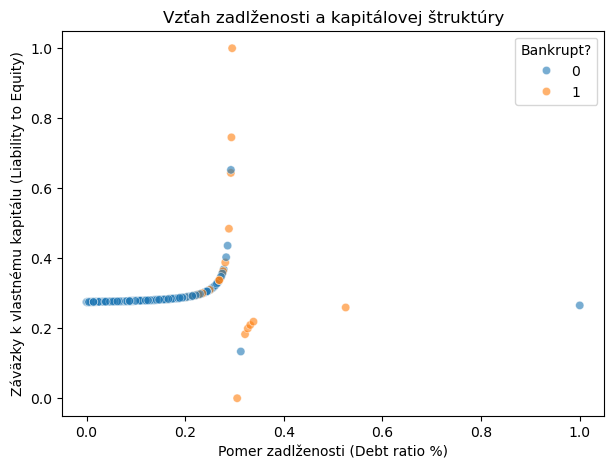

In [76]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x='Debt ratio %',
    y='Liability to Equity',
    hue='Bankrupt?',
    alpha=0.6
)

plt.title("Vzťah zadlženosti a kapitálovej štruktúry")
plt.xlabel("Pomer zadlženosti (Debt ratio %)")
plt.ylabel("Záväzky k vlastnému kapitálu (Liability to Equity)")

plt.show()

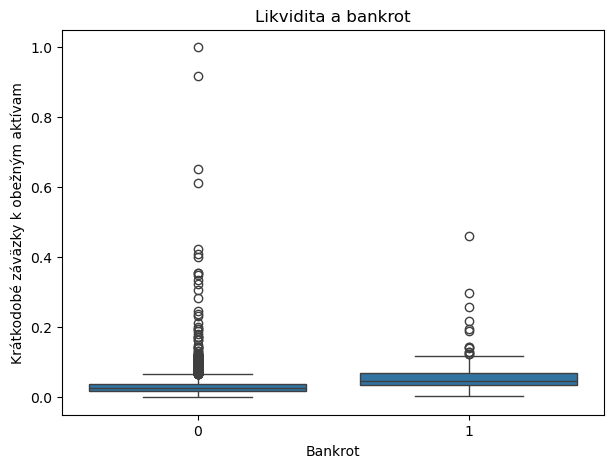

In [78]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x='Bankrupt?',
    y='Current Liability to Current Assets'
)

plt.title("Likvidita a bankrot")
plt.xlabel("Bankrot")
plt.ylabel("Krátkodobé záväzky k obežným aktívam")
plt.show()


#Graf ukazuje, že bankrotujúce podniky majú vyššie krátkodobé záväzky
#k obežným aktívam než nebankrotujúce. To znamená horšiu likviditu. 
#Vyššie hodnoty teda súvisia s väčším rizikom bankrotu.

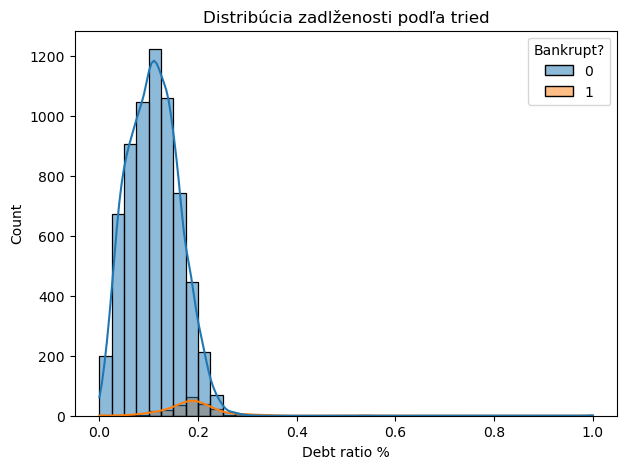

In [81]:
plt.figure(figsize=(7,5))

sns.histplot(
    data=df,
    x='Debt ratio %',
    hue='Bankrupt?',
    bins=40,
    kde=True
)

plt.title("Distribúcia zadlženosti podľa tried")
plt.show()


#Graf ukazuje rozdelenie pomeru zadlženosti (Debt ratio %) pre obe triedy. 
#Nebankrotujúce podniky (0) sú sústredené pri nižších hodnotách, zatiaľ čo bankrotujúce podniky (1) 
#sa častejšie vyskytujú pri vyššej zadlženosti. To naznačuje, že vyšší dlh zvyšuje riziko bankrotu.